# IMMUN 306QC Python Bootcamp / Session 3
*Ralph Estanboulieh (2026)*

*This notebook was created **without** the use of AI.*

In the last session we learned about reading and handling tabular data using Panda's, Python's flagship data wrangling library. In this session, we first explore NumPy, Python's fundamental math and linear algebra library, and then look at how data can be visualized in Python with Matplotlib. 

## Basic math with NumPy

Now that we can read and clean numerical data, we need a way to do advanced calculations with it. However, while Python lists and dictionaries can be useful at storing data, doing math with them is highly inefficient. NumPy, which stands for numerical Python, is an extremely popular and widely used open-source library that can help us do just that, and then some, like generating random numbers. You might point out that Pandas already has efficient numerical capabilities, but those are actually all built off of NumPy.

As always, I recommend you browse through the [NumPy docs](https://numpy.org/doc/stable/user/absolute_beginners.html) to familiarize yourself with its powerful features. Another very helpful resource (especially for visual learners) is [The Visual Guide to NumPy](https://medium.com/better-programming/numpy-illustrated-the-visual-guide-to-numpy-3b1d4976de1d) by Lex Maximov.


First, let's import it.

In [2]:
import numpy as np
print(np.__version__) # version should be > 2.5

2.5.3


### The NumPy array

The cornerstone of NumPy is the array. NumPy Arrays can surprisingly contain up to 32 dimensions! Hopefully, you will only need to deal with one-, two-, and very rarely three-dimensional ones in the vast majority of applications. 

There are many ways to create an array, the most basic of which is to start with a simple list and feed it to `np.array()` to create a **one-dimensional** array:

In [18]:
a1 = np.array([1,2,3,4,5,6,7])
a1

array([1, 2, 3, 4, 5, 6, 7])

If we wish to create a two-dimensional array, we can use a list of lists:

In [73]:
a2 = np.array(
    [[1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16],
    [17, 18, 19, 20]]
)
a2

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

And if we stack 2D arrays into an array, we can get a 3D array! (Notice the triple brackets!)

In [74]:
a3 = np.array([a2,a2,a2])
a3

array([[[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [17, 18, 19, 20]],

       [[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [17, 18, 19, 20]],

       [[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [17, 18, 19, 20]]])

### Array attributes

Attributes are constant values that are properites of an object/class and can be accessed via the dot notation. Important attributes of an array include:

1) `ndim`: the number of dimensions

In [75]:
for a in [a1,a2,a3]:
    print(a.ndim)

1
2
3


2) `shape`: The shape of the array, the number of elements along each dimension (for 2D, it's `nrows, ncols`)

In [76]:
for a in [a1,a2,a3]:
    print(a.shape)

(7,)
(5, 4)
(3, 5, 4)


3) `size`: the total number of elements in the array

In [77]:
for a in [a1,a2,a3]:
    print(a.size)

7
20
60


4) `dtype`: the type of the data in the array, which mimics the `dtypes` attribute of a Pandas DataFrame. (Usually, arraus are **homogeneous**, meaning they can only contain one data type.)

In [78]:
for a in [a1,a2,a3]:
    print(a.dtype)

int64
int64
int64


### Functions that create basic arrays

NumPy has other ways of creating arrays:

1) `np.zeros()`: returns an array of zeros with a given shape

In [79]:
np.zeros((3,7)) # try changing the shape!

array([[0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.]])

2) `np.ones()`: returns an array of ones with a given shape

In [80]:
np.ones((3,2,4))

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.]]])

3) `np.arange()`: extremely useful, is the NumPy equivalent of Python's `range()`, creates a range of numbers given `(start, stop, step)`

In [81]:
print(np.arange(12))
print(np.arange(3, 12))
print(np.arange(1, 30, 2))

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[ 3  4  5  6  7  8  9 10 11]
[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29]


4) `np.linspace()`: creates an array of values that are linearly interspaced between two given (and included) boundary values

In [82]:
np.linspace(3, 10, num=5)

array([ 3.  ,  4.75,  6.5 ,  8.25, 10.  ])

5) `np.eye`: creates the identity matrix given the length of the diagonal

In [83]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [84]:
np.eye(3,5)

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [86]:
np.eye(8,k=3) # try negative k

array([[0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

### Indexing and slicing NumPy arrays

<center><img src="figures/np_indexing.png"></center>

Indexing (accessing individual elements) and slicing (viewing slices) NumPy arrays is (almost) as simple as indexing and slicing basic Python lists. For 1D array, it is the same:

In [87]:
print(a1)
print(a1[2]) # 3rd element
print(a1[:4]) # first 4 elements
print(a1[3:]) # elements after (and including) 4th element
print(a1[2:6]) # 3rd to 6th elements
print(a1[0:7:2]) # start 0, end 7, step 2 (every other element)
print(a1[::3]) # every 3rd element
print(a1[::-1]) # every element, reversed
print(a1[4::-1]) # reversed, starting from 5th element

[1 2 3 4 5 6 7]
3
[1 2 3 4]
[4 5 6 7]
[3 4 5 6]
[1 3 5 7]
[1 4 7]
[7 6 5 4 3 2 1]
[5 4 3 2 1]


For 2D arrays, it's the same, except we first index/slice the rows, then the columns:

In [114]:
print(a2)
print(f"> a2[2]\n{a2[2]}") # 3rd row
print(f"> a2[2, :]\n{a2[2, :]}") # also 3rd row
print(f"> a2[2:4]\n{a2[2:4]}") 
print(f"> a2[1:3]\n{a2[1:3]}") 
print(f"> a2[3,2]\n{a2[3, 2]}") # 4th row, 3rd column
print(f"> a2[:, 1]\n{a2[:, 1]}") # 2nd column
print(f"> a2[:, :3]\n{a2[:, :3]}") # first 3 columns
print(f"> a2[1:-1, 1:-1]\n{a2[1:-1, 1:-1]}") # middle sub-matrix
print(f"> a2[::2, ::2]\n{a2[::2, ::2]}") # every other element in both dimesions

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]
 [17 18 19 20]]
> a2[2]
[ 9 10 11 12]
> a2[2, :]
[ 9 10 11 12]
> a2[2:4]
[[ 9 10 11 12]
 [13 14 15 16]]
> a2[1:3]
[[ 5  6  7  8]
 [ 9 10 11 12]]
> a2[3,2]
15
> a2[:, 1]
[ 2  6 10 14 18]
> a2[:, :3]
[[ 1  2  3]
 [ 5  6  7]
 [ 9 10 11]
 [13 14 15]
 [17 18 19]]
> a2[1:-1, 1:-1]
[[ 6  7]
 [10 11]
 [14 15]]
> a2[::2, ::2]
[[ 1  3]
 [ 9 11]
 [17 19]]


Note: indexing and slicing arrays returns a **non-copy view** of the sliced array, which means that altering the view will alter the original array. If you wish to only alter the array slice without affecting the original array, copy the slice using `.copy()`. 

Another useful way to select values in an array is indexing using a boolean array, that is an array where every value is either `True` or `False`. The boolean array has to be of the same shape as the source array. Say we want to select all the values that are greater than 7:

In [365]:
a2 > 7

array([[False, False, False, False],
       [False, False, False,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [366]:
a2[a2 > 7]

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

We can also use more complex conditions using the and-operator `&` and or-operator `|`:

In [368]:
a2[(a2 <= 5) | (a2 > 10)]

array([ 1,  2,  3,  4,  5, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [370]:
a2[(a2 > 6) & (a2 <= 12)]

array([ 7,  8,  9, 10, 11, 12])

### Note on array dimensions

Always pay attention to the dimensions and shapes of your arrays. Very importantly, a 1D array is **not** the same as a single row in a 2D array. You can tell the difference by the number of square brackets `[]` flanking the array.

In [266]:
a1d = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [241]:
a2d = np.array([[0,1,2,3,4,5,6,7,8,9]])
a2d

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

You can also tell the difference by looking at the shapes and number of dimensions:

In [242]:
print(a1d.ndim, a2d.ndim)
print(a1d.shape, a2d.shape)

1 2
(10,) (1, 10)


While `a1d` is a 1D array of shape `(10,)`, `a2d` is a 2D array of shape `(1,10)` (1 row, 10 columns). This distinction is very important in a lot of contexts, including many math operations, such as matrix multiplication.

Moreover, keep in mind that slicing a single row or column of a 2D array will usually return a 1D array:

In [250]:
a2

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

In [251]:
a2[:, 1] # the second column of a2

array([ 2,  6, 10, 14, 18])

To get back a proper 2D array, there are at least two methods: (1) slice using the `[start:end]` notation:

In [252]:
a2[:, 0:1]

array([[ 1],
       [ 5],
       [ 9],
       [13],
       [17]])

Or (2) put the index in a list:

In [254]:
a2[:, [1]]

array([[ 2],
       [ 6],
       [10],
       [14],
       [18]])

If you already have a 1D array, you can turn it into a 2D array using `np.newaxis`:

In [256]:
a1d[:, np.newaxis] # makes it a 2D column

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5],
       [6],
       [7],
       [8],
       [9]])

In [270]:
a1d[np.newaxis, :] # makes it a 2D row

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

(Notice the double brackets.)

Or you could use `reshape()` or `expand_dims()`:

In [268]:
a1d.reshape((1, 10))

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

In [269]:
np.expand_dims(a1d, axis=0)

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

### Reshaping arrays

You can easily change the shape of an array via `ravel()`, which unravels multi-dimensional arrays, and `reshape()`, takes an array and reshapes it to your desired shape (of course, shape must match the array size, otherwise expect an error).

In [117]:
a = np.arange(1, 21)
a

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [123]:
a.reshape(4,5) # also try (5,4), (20, 1), and (1,20)

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20]])

In [126]:
a2.ravel()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

Of course, no need to un`ravel()` an array before reshaping it

In [127]:
a2.reshape(2, 10)

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]])

Don't forget about transposition:

In [128]:
a2.T

array([[ 1,  5,  9, 13, 17],
       [ 2,  6, 10, 14, 18],
       [ 3,  7, 11, 15, 19],
       [ 4,  8, 12, 16, 20]])

### Stacking arrays

NumPy also offers easy ways to join arrays together. This can be done with `concatenate()`, which requires arrays with the same number of dimensions, or `vstack()` and `hstack()`, which can stack 1D and 2D arrays vertically and horizontally, respectively (as long as the shapes match).

In [164]:
a = np.arange(1, 5)
b = np.arange(5, 9)
print(a, b)

[1 2 3 4] [5 6 7 8]


In [165]:
np.concatenate([a,b])

array([1, 2, 3, 4, 5, 6, 7, 8])

In [166]:
np.vstack([a,b])

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [167]:
np.hstack([a, b])

array([1, 2, 3, 4, 5, 6, 7, 8])

Doing the same with 2D arrays:

In [172]:
np.concatenate([a2, a2], axis=0) # try axis=1

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20],
       [ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

In [173]:
np.vstack([a2, a2])

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20],
       [ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

In [174]:
np.hstack([a2, a2])

array([[ 1,  2,  3,  4,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  5,  6,  7,  8],
       [ 9, 10, 11, 12,  9, 10, 11, 12],
       [13, 14, 15, 16, 13, 14, 15, 16],
       [17, 18, 19, 20, 17, 18, 19, 20]])

Stacking a 1D array on top of a 2D array:

In [175]:
np.vstack([a, a2])

array([[ 1,  2,  3,  4],
       [ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

You can also tile arrays with `np.tile()`, which takes an array and a desired tiling shape, and returns an array where each element of the tiling shape is replaced by the array itself:

In [204]:
a

array([1, 2, 3, 4])

In [207]:
print(np.tile(a, 3))
print(np.tile(a, (2,3)))

[1 2 3 4 1 2 3 4 1 2 3 4]
[[1 2 3 4 1 2 3 4 1 2 3 4]
 [1 2 3 4 1 2 3 4 1 2 3 4]]


In [208]:
b = np.array([[1,2,3], [4,5,6]])
b

array([[1, 2, 3],
       [4, 5, 6]])

In [214]:
np.tile(b, 2)

array([[1, 2, 3, 1, 2, 3],
       [4, 5, 6, 4, 5, 6]])

In [212]:
np.tile(b, (3,1))

array([[1, 2, 3],
       [4, 5, 6],
       [1, 2, 3],
       [4, 5, 6],
       [1, 2, 3],
       [4, 5, 6]])

### Splitting arrays

Splitting arrays is also possible via `split()`, `hsplit()`, and `vsplit()`.

In [178]:
x = np.arange(20)
x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [184]:
np.split(x, 2) # split in half

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])]

In [196]:
np.split(x, [3, 12, 17]) # split at indexes 3, 12, and 17

[array([0, 1, 2]),
 array([ 3,  4,  5,  6,  7,  8,  9, 10, 11]),
 array([12, 13, 14, 15, 16]),
 array([17, 18, 19])]

Note how using $N$ split indexes generates $N+1$ subarrays. Now trying this on 2D arrays:

In [197]:
np.hsplit(a2, 2) # split horizontally, in half

[array([[ 1,  2],
        [ 5,  6],
        [ 9, 10],
        [13, 14],
        [17, 18]]),
 array([[ 3,  4],
        [ 7,  8],
        [11, 12],
        [15, 16],
        [19, 20]])]

In [198]:
np.hsplit(a2, [1,3])

[array([[ 1],
        [ 5],
        [ 9],
        [13],
        [17]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11],
        [14, 15],
        [18, 19]]),
 array([[ 4],
        [ 8],
        [12],
        [16],
        [20]])]

In [199]:
np.vsplit(a2, [1,3])

[array([[1, 2, 3, 4]]),
 array([[ 5,  6,  7,  8],
        [ 9, 10, 11, 12]]),
 array([[13, 14, 15, 16],
        [17, 18, 19, 20]])]

### Basic operations

Now the cool math. Like we saw with Pandas (because it is built around NumPy), we can do math extremely efficiently with NumPy arrays thanks to NumPy's vectorized implementation of these operations, which is incredibly faster than having a for loop iterate over each element of an array.

The simplest operation is that between an array and a scalar (a single number), which applies the same operation independently to every element in the array:

In [305]:
a = np.array([[1,2,3], [4,5,6]])
a

array([[1, 2, 3],
       [4, 5, 6]])

In [306]:
print(a + 20)
print(a - 10)
print(a / 2)
print(a * 3.4)
print(a ** 2)
print(a % 3)
print(1/a)

[[21 22 23]
 [24 25 26]]
[[-9 -8 -7]
 [-6 -5 -4]]
[[0.5 1.  1.5]
 [2.  2.5 3. ]]
[[ 3.4  6.8 10.2]
 [13.6 17.  20.4]]
[[ 1  4  9]
 [16 25 36]]
[[1 2 0]
 [1 2 0]]
[[1.         0.5        0.33333333]
 [0.25       0.2        0.16666667]]


The same thing applies to comparison functions:

In [307]:
print(a == 4)
print(a > 3)

[[False False False]
 [ True False False]]
[[False False False]
 [ True  True  True]]


When it comes to doing math with arraws only, the logic is also very intuitive. Usually, operations will also be down element-wise:

In [308]:
b = np.array([[10, 20, 30], [40, 50, 60]])
b

array([[10, 20, 30],
       [40, 50, 60]])

In [309]:
print(a + b)
print(a - b)
print(a * b)
print(b / a)
print(a < b)

[[11 22 33]
 [44 55 66]]
[[ -9 -18 -27]
 [-36 -45 -54]]
[[ 10  40  90]
 [160 250 360]]
[[10. 10. 10.]
 [10. 10. 10.]]
[[ True  True  True]
 [ True  True  True]]


What if the arrays don't match exactly in shape? Then, if the shapes allow, **broadcasting** is done. Broadcasting is a mechanism that carries out element-wise operations with arrays of different (but compatible) shapes by essentially tiling at least one of the arrays so that the shapes can match. For example, say we want to add a $1\times 3$ single row array to a $3\times 3$ array. Broadcasting replicates the single row 3 times so that it matches the shape of the other array, which then makes the element-wise addition straightforward:

In [310]:
a2

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

In [231]:
a2 + np.array([100, 200, 300, 400])

array([[101, 202, 303, 404],
       [105, 206, 307, 408],
       [109, 210, 311, 412],
       [113, 214, 315, 416],
       [117, 218, 319, 420]])

Broadcasting is also technically what happens when carrying out an operation between an array and a scalar. Here is a helpful schematic from the visual guide to NumPy I mentioned at the start of this tutorial:

<center><img src="figures/broadcasting.png"></center>

What if we wanted to add by broadcasting columnwise?

In [271]:
a2 + np.array([100, 200, 300, 400, 500])[:, np.newaxis]

array([[101, 102, 103, 104],
       [205, 206, 207, 208],
       [309, 310, 311, 312],
       [413, 414, 415, 416],
       [517, 518, 519, 520]])

The outer product case, which also applies to other basic operations, is especially fascinating:

In [282]:
a = np.array([[1,2,3]])
b = np.array([1,2,3])[:, np.newaxis]

In [283]:
b

array([[1],
       [2],
       [3]])

In [289]:
a + b # try other basic operations!

array([[2, 3, 4],
       [3, 4, 5],
       [4, 5, 6]])

For broadcasting to work, generally, the two arrays must share shapes in any one of the dimensions (e.g same number of rows or columns) while the other dimension is 1 for at least one of the arrays.

### Universal functions

Actually, it turns out that the functions above are member of a family of functions NumPy calls **universal functions**. These are all functions that operate ultra-efficiently on arrays in an element-wise manner (while also supporting broadcasting). These functions cover a lot of ground, mathematically speaking. In addition to the basic operations mentioned above (addition, multiplication, etc.), they include exponents, logarithms, square root, matrix multiplication, trigonometry, rounding, and so many more. A comprehensive list of universal functions can be found [here](https://numpy.org/doc/stable/reference/ufuncs.html). Here are a few examples:

In [297]:
x = np.arange(1, 10)
x

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [298]:
np.power(x, 3)

array([  1,   8,  27,  64, 125, 216, 343, 512, 729])

In [299]:
np.sqrt(x)

array([1.        , 1.41421356, 1.73205081, 2.        , 2.23606798,
       2.44948974, 2.64575131, 2.82842712, 3.        ])

In [300]:
np.log2(x)

array([0.        , 1.        , 1.5849625 , 2.        , 2.32192809,
       2.5849625 , 2.80735492, 3.        , 3.169925  ])

In [326]:
np.exp(x)

array([2.71828183e+00, 7.38905610e+00, 2.00855369e+01, 5.45981500e+01,
       1.48413159e+02, 4.03428793e+02, 1.09663316e+03, 2.98095799e+03,
       8.10308393e+03])

In [316]:
rads = np.radians(x*20) # degrees to radians
rads

array([0.34906585, 0.6981317 , 1.04719755, 1.3962634 , 1.74532925,
       2.0943951 , 2.44346095, 2.7925268 , 3.14159265])

In [320]:
sinuses = np.sin(rads)
sinuses

array([3.42020143e-01, 6.42787610e-01, 8.66025404e-01, 9.84807753e-01,
       9.84807753e-01, 8.66025404e-01, 6.42787610e-01, 3.42020143e-01,
       1.22464680e-16])

In [324]:
np.round(sinuses, 3)

array([0.342, 0.643, 0.866, 0.985, 0.985, 0.866, 0.643, 0.342, 0.   ])

In [325]:
np.arcsin(sinuses)

array([3.49065850e-01, 6.98131701e-01, 1.04719755e+00, 1.39626340e+00,
       1.39626340e+00, 1.04719755e+00, 6.98131701e-01, 3.49065850e-01,
       1.22464680e-16])

In [329]:
y = np.array([2,5,1,3,7,6,3,12,4])
y

array([ 2,  5,  1,  3,  7,  6,  3, 12,  4])

In [330]:
np.maximum(x, y) # takes the maximum between x and y at each index

array([ 2,  5,  3,  4,  7,  6,  7, 12,  9])

### Other useful functions

NumPy arrays also have other very useful methods, like `min()` and `max()` and `mean()`, a comprehensive list of which can be found [here](https://numpy.org/doc/stable/reference/arrays.ndarray.html#calculation). Many of these functions take the `axis` argument, which when set to `0` carries out the operation down the rows (which yields one result per column), and when set to `1` carries out the operation down the columns (which yields one result per row).

In [331]:
x.sum()

np.int64(45)

In [338]:
a2.sum()

np.int64(210)

In [334]:
a2.sum(axis=0) 

array([45, 50, 55, 60])

Also, did you know that you can easily count the number of `True` values using sum? This is because the bools `True` and `False` have implicit values 1 and 0.

In [374]:
(a2 > 10).sum() # the number of values > 10

np.int64(10)

In [337]:
a2.max(axis=1)

array([ 4,  8, 12, 16, 20])

In [339]:
a2.mean() 

np.float64(10.5)

In [340]:
a2.mean(axis=1)

array([ 2.5,  6.5, 10.5, 14.5, 18.5])

In [342]:
a2.var(axis=0)

array([32., 32., 32., 32.])

In [343]:
x.cumsum()

array([ 1,  3,  6, 10, 15, 21, 28, 36, 45])

In [344]:
x.cumprod()

array([     1,      2,      6,     24,    120,    720,   5040,  40320,
       362880])

### Sorting arrays

Sorting arrays can be easily done with `np.sort()`, which returns a sorted copy of the array without modifying the original array:

In [358]:
a = np.array([11,3,5,1,8,2,9,4,12,0,10,6,7])
print(np.sort(a))
print(a)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
[11  3  5  1  8  2  9  4 12  0 10  6  7]


To sort the original array in-place, use `array.sort()`

In [359]:
a.sort()
print(a)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12]


Another useful NumPy sorting function is `argsort()`, which indirectly sorts an array and returns **not** the sorted array but the indexes corresponding to the sorted elements!

In [360]:
a = np.array([11,3,5,1,8,2,9,4,12,0,10,6,7])
np.argsort(a)

array([ 9,  3,  5,  1,  7,  2, 11, 12,  4,  6, 10,  0,  8])

This means that the smallest element in `a` is the one at index `8` (the 9th element), the second smallest one is the one at index `3` (the 4th element), and so on. To illustrate this point, let's list the elements of `a` according to the `argsort`ed indexes: 

In [361]:
for i in np.argsort(a):
    print(a[i], end=' < ')

0 < 1 < 2 < 3 < 4 < 5 < 6 < 7 < 8 < 9 < 10 < 11 < 12 < 

Two other functions related to `argsort()` are `argmax()` and `argmin()`, which return the **index** of the maximum and minimum values in the array, respectively:

In [363]:
imax = np.argmax(a)
imin = np.argmin(a)
print(f"argmax index: {imax} | corresponding element: {a[imax]}")
print(f"argmin index: {imin} | corresponding element: {a[imin]}")

argmax index: 8 | corresponding element: 12
argmin index: 9 | corresponding element: 0


### Random number generation

One very important tool in scientific computation is random number generation, which can be useful in various settings including simulation and optimization algorithms that use random sampling. NumPy offers a way to generate random numbers through the `numpy.random` module. 

To generate random numbers with NumPy, we must first create a `Generator` instance with `default_rng()` (`rng` stands for random number generator). The `Generator` class contains all the methods we might need, including generating random integers, shuffling arrays, and sampling from the distributions you fancy. More information about the `Generator` class, including a comprehensive list of the methods and tools it offers, can be found [here](https://numpy.org/doc/stable/reference/random/generator.html#numpy.random.Generator). 

In [377]:
rng = np.random.default_rng()
type(rng)

numpy.random._generator.Generator

In [381]:
rng.integers(low=0, high=10, size=20) # included low, excluded high

array([1, 2, 7, 0, 2, 9, 2, 8, 7, 6, 6, 5, 9, 9, 8, 6, 9, 5, 5, 3])

In [382]:
rng.random(size=10) # uniform [0, 1)

array([0.69708893, 0.60552349, 0.83471439, 0.69767064, 0.9614606 ,
       0.89914205, 0.75068369, 0.36150384, 0.28870029, 0.82980732])

In [390]:
a = np.arange(10, 20)
a

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

`Generator.choice()` generates a random sample from a given array. Other than specifying the input array `a`, you can specify the `size` (how many samples), whether sampling is done with or without `replace`ment, and even `p`, an array of probabilities associated with each element of `a`, in case some elements are more likely to be sampled than others.

In [395]:
rng.choice(a, size = 10, replace = True)

array([12, 12, 19, 14, 15, 17, 15, 10, 18, 18])

Let's try making the sampling biased towards the first half of the array!

In [404]:
biased_p = np.array(([0.8/5] * 5)+ ([0.2/5] * 5))
print(biased_p)
print(biased_p.sum()) # must sum up to 1

[0.16 0.16 0.16 0.16 0.16 0.04 0.04 0.04 0.04 0.04]
1.0


In [407]:
sample = rng.choice(a, size = 5000, replace = True, p = biased_p)

`np.unique()` primarily returns the unique values in an array, but can also return their counts when `return_counts` is set to `True`.

In [412]:
values, counts = np.unique(sample, return_counts = True) 
[print(f"{v}: {c}") for v, c in zip(values, counts)];

10: 829
11: 794
12: 832
13: 802
14: 764
15: 192
16: 176
17: 205
18: 209
19: 197


The sampling is clearly biased!

In [413]:
counts/counts.sum()

array([0.1658, 0.1588, 0.1664, 0.1604, 0.1528, 0.0384, 0.0352, 0.041 ,
       0.0418, 0.0394])

We can also permute a sequence with `permutation()` (which is the same as sampling without replacement the same number of times as the size of the array)

In [417]:
rng.permutation(a)

array([13, 10, 19, 16, 11, 18, 17, 14, 15, 12])

The `Generator` instance also offers a very convenient way to sample from discrete and 
continuous probability distributions (the comprehensive list can be found [here](https://numpy.org/doc/stable/reference/random/generator.html#distributions)), you just generally need to provide the parameter of the distribution and the desired size of the sample. Let's try it with the Normal distribution (aka the Gaussian), which looks like a bell:

In [428]:
rng.normal(loc=10, scale=1, size=10)

array([10.30969756, 10.5327897 , 11.87587329, 10.24560672,  8.38656761,
       10.10267293,  9.61586408,  9.97988526, 10.4757203 ,  9.84871534])

I know we haven't covered data visualization yet, but let's just cheat for a moment and check the shape of the distrbution!

In [429]:
x = rng.normal(loc=10, scale=1, size=5000)

In [430]:
import matplotlib.pyplot as plt

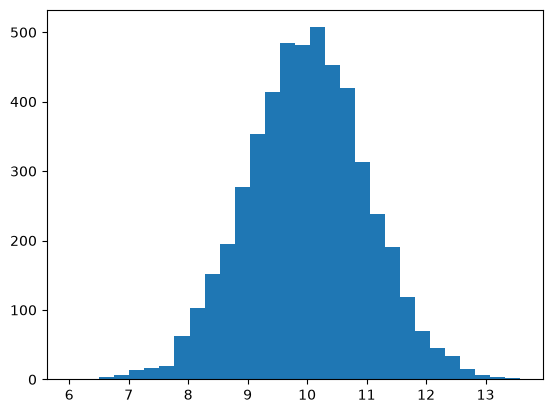

In [432]:
plt.hist(x, bins=30);

Looks great! Let's try it with the Poisson distribution:

In [441]:
x = rng.poisson(lam=1, size=5000)

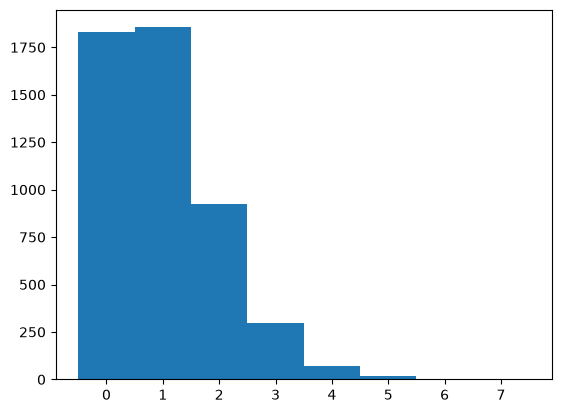

In [442]:
plt.hist(x, bins = np.arange(-0.5, 8, 1));

## Data visualization

The three most relevant data visualization libraries in Python are the following:
1) `Matplotlib`: the bread and butter of plotting in Python. It is designed to emulate plotting with MATLAB (hence the name).
2) `Pandas` itself, in addition to be a data processing library, possesses data plotting functions that directly use `Matplotlib`.
3) `Seaborn`, while also built with and on top of `Matplotlib`, offers a fancier array of plotting capabilities. However, because it is high-level, it is not as customizable as `Matplotlib`. 
There are of course other libraries that one can use (`Plotly` comes to mind) that are out of the scope of this bootcamp, but by all means, feel free to explore them as well!

Since `Matplotlib` is the bread and butter of mainsteam Python plotting and the foundation of many common visualization libraries, we will mainly deal with `Matplotlib` in this session to really understand the mechanics of plotting with Python. 

### Getting started

First let's import the `matplotlib.pyplot` library and give it the alias `plt` to make it easier to call it. 

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
print(mpl.__version__)

3.11.1


Now let's get right to plotting a simple line plot, just to get a sense of what we're dealing with.

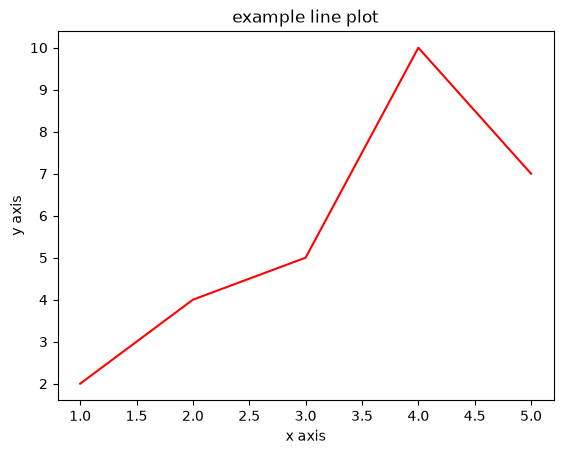

In [50]:
fig, ax = plt.subplots()
ax.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
ax.set_xlabel('x axis')
ax.set_ylabel('y axis')
ax.set_title("example line plot")
plt.show()

Easy! Now let's break it down:
* `plt.subplots()` creates a Figure object (`fig`) that contains a single Axes object (`ax`), more on what this means later.
* `ax.plot()` calls the `plot()` method inside the Axes object, which takes the x coordinates first, then the y coordinates, then any optional styling arguments (like `color`) in this case.
* `ax.set_xlabel()`, `ax.set_ylabel()`, and `ax.set_title()` are all methods that change the x and y axis labels and the title of the Axes object.
* `plt.show()` usually displays all active figures, which in a Jupyter notebook is simply the figure that was just coded. However, it is not a necessary call because Jupyter automatically calls it when running a code cell, so we'll drop it from now on.


### The anatomy of a figure

Here is an amazingly helpful schematic pulled straight from the [Matplotlib docs](https://matplotlib.org/stable/users/explain/quick_start.html#parts-of-a-figure).

<center><img src='figures/anatomy.png'></center>

The `Figure` is essentially the big rectangular patch that contains everything that is drawn. However, a Figure is basically nothing without an `Axes` object, which is the rectangular area that actually contains the x and y axes, the plot itself, as well as most text drawn on the plot (x and y labels, the title, and more). The x and y axes are represented by `Axis` objects (different from the `Axes`, which is the class that contains them), which set the scale (how the data is distributed on a plot), the limits, and generate the ticks.   

Thus, the (oversimplified) hierarchy of objects in Matplotlib is the following:
```
Figure
    > Axes
        > XAxis, YAxis
```

This layout of `Figures` that contains one or many `Axes` (or even more subfigures, which we will not explore here) enables a lot of customization, most importantly the ability to draw a figure with multiple subplots using the `subplots()` function, which first takes two numbers: the number of rows and then the number of columns.


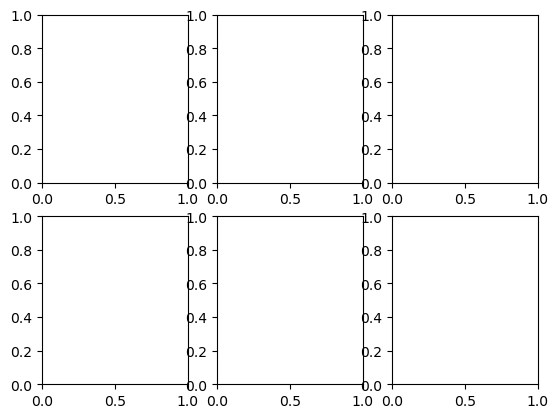

In [72]:
fig, ax = plt.subplots(2,3)

Bothere by the overlapping tick labels and spines? Me too. This is because the font sizes are set to a default value that might be too big when the figures get too crowded. There are at least two ways to deal with it. (1) You could use `layout="constrained"`, which is an algorithm that goes over the elements in the figure and shrinks them so there is no overlab:

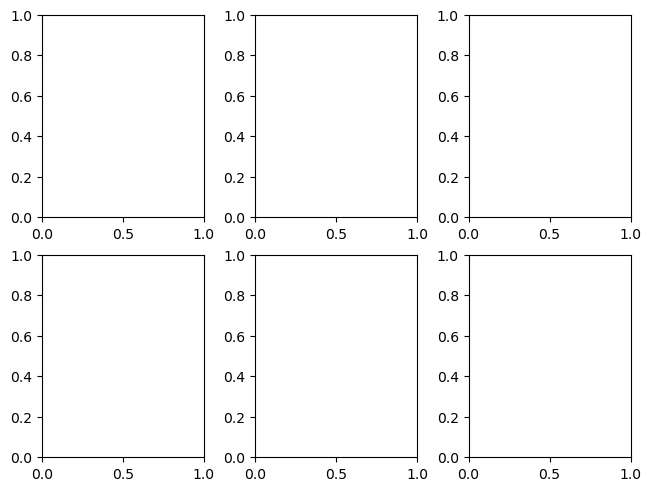

In [73]:
fig, ax = plt.subplots(2,3, layout='constrained')

Or (2) you could simply make the figure larger using the `figsize` argument, which takes a tuple containing the width, the height, and then optionally the units (`"in"` \[the default value\] or `"cm"` or `"px"`; but only in the latest version of `matplotlib`), then adding the subplots:

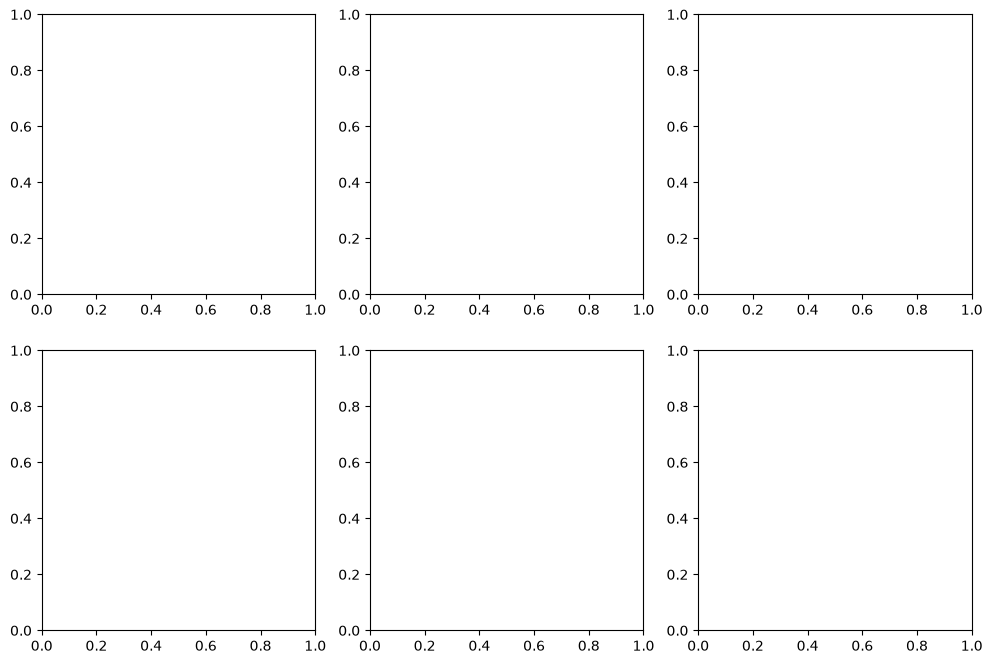

In [25]:
fig, axes = plt.subplots(2,3, figsize=(12,8, 'in'))

To access each of these suplots, we simply index our way through the `axes` variable (which you could call anything you want, but `axes` is the cannon), which is a matrix in which each element is an `Axes` object ready to be used. The way we access an element in an array is also with square brackets containing first the row index and second the column index of the element: `[row, col]`.

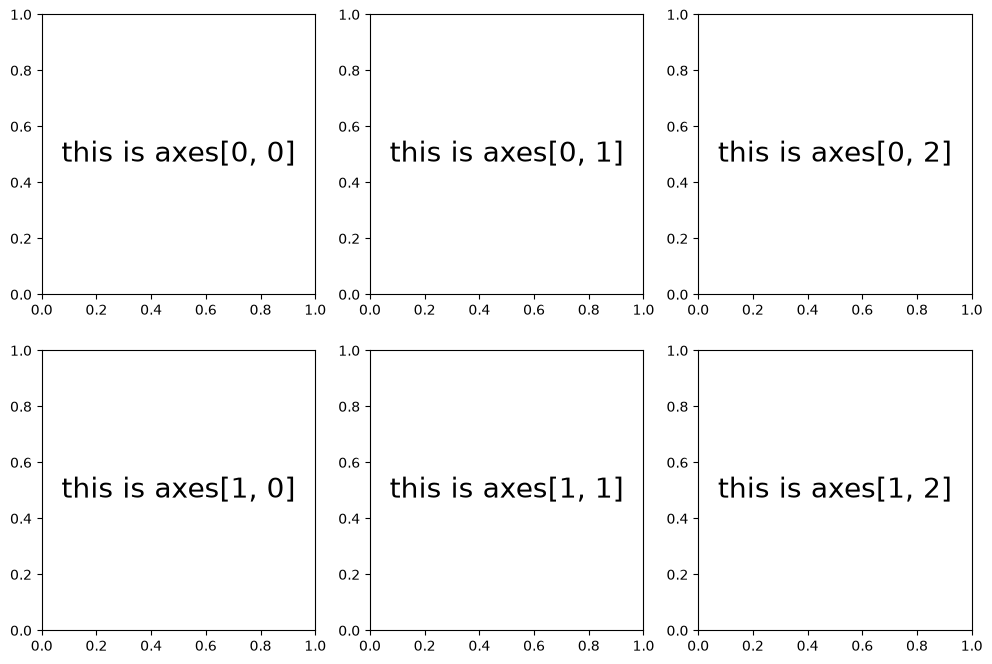

In [26]:
fig, axes = plt.subplots(2,3,figsize=(12,8))

for i in range(2):
    for j in range(3):
        axes[i, j].text(0.5, 0.5, 
                        f"this is axes[{i}, {j}]", 
                        ha='center', va='center', # (h)orizontal/(v)ertical (a)lignment
                        fontsize=20)

(Note that when adding text to a plot, all you need are the x and y coordinates, and the text itself. You can also specify the horizontal and vertical alignment using the `ha` and `va` arguments, which I set to `"center"` here.)

To illustrate this point further, here's another cool function that can also divide the `Figure` in a much more sophisticated way:

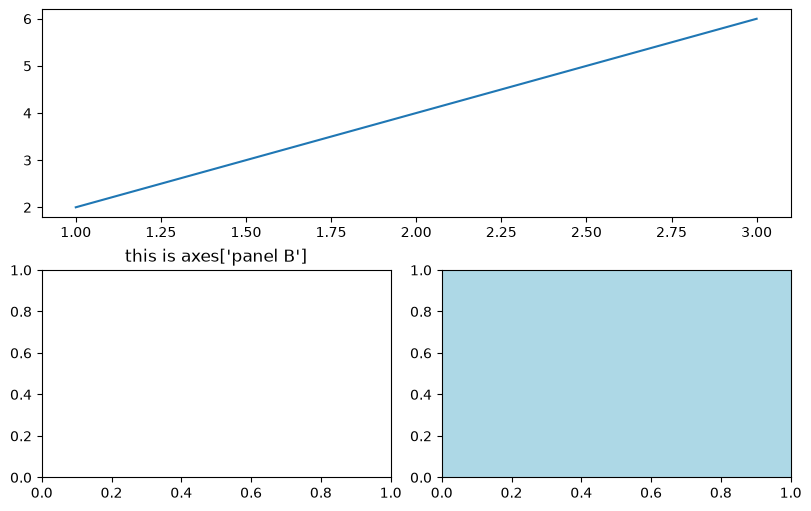

In [39]:
fig, axes = plt.subplot_mosaic([
    ['panel A', 'panel A'],
    ['panel B', 'panel C']
], figsize=(8, 5), layout="constrained")

axes['panel A'].plot([1,2,3], [2,4,6])
axes['panel B'].set_title("this is axes['panel B']")
axes['panel C'].set_facecolor('lightblue')

### The pyplot coding style

The coding style above, where we directly manipulate `Figure` and `Axes` objects, is called the object-oriented approach. There is another, perhaps slightly simpler (but also slightly messier) style called the pyplot style. This style was design to emulate MATLAB plotting, so it can also be called the MATLAB style.  

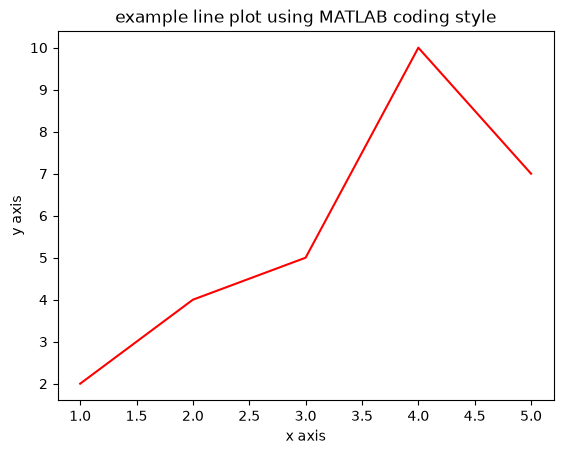

In [96]:
plt.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('example line plot using MATLAB coding style');

Some main differences to be pointed out:
* We did not first need to create a subplot using `plt.subplots()`; we just used `plot()` directly. Notice that this is `pyplot.plot()`, not `Axes.plot()` (which we used in the very first example). Here, `pyplot.plot()` automatically creates the Figure and Axes objects, making reasonable assumptions about what we want them to look like.
* The function names are shorter: simply `xlabel`, `ylabel`, and `title` instead of `set_xlabel`, `set_ylabel`, and `set_title`

This extra convenience is.. well, very convenient, especially for quick and dirty data exploration. However, it does come at a cost, as it does not yield full power and customization over plotting as seamlessly as the object-oriented style. And very importantly, since we do not specify which Axes to plot in, this code makes assumptions about which Axes is "active" and which are "inactive", and only draws on active plots. (Just like MATLAB!) This also why this coding style is also called **state-based**, because it depends on the active/inactive states of the plots. If you are not coding in a development environment that allows for multiple active plots at the same time (i.e. not Jupyter), this can get very confusing.

To concretize this idea of an "active" plot, here's how we create a figure with multiple subplots using state-based, pyplot/MATLAB-style coding. We first call `pyplot.subplot()`, which creates and activates one subplot (**not the same as** `pyplot.subplots()`, which creates multiple subplots at the same time). `pyplot.subplot()` takes at least 3 arguments in this order: the number of rows, the number of columns, and then the index of the subplot to activate (`1` for the first one, `2` for the second one, and so on, going left to right, top to bottom): 

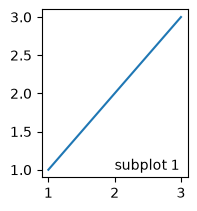

In [94]:
plt.subplot(2,3,1) # 2 rows, 3 columns, start with the first subplot
plt.plot([1,2,3], [1,2,3])
plt.text(2,1,'subplot 1');

Notice how the subplot is smaller, but there are no other subplots waiting to be populated like the examples above. We have to activate them manually, and in any order we want:

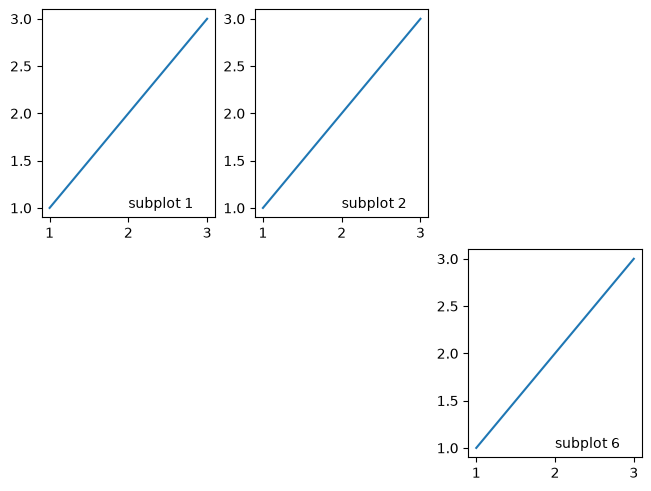

In [95]:
plt.figure(layout='constrained')
plt.subplot(2,3,1) # 2 rows, 3 columns, start with the first subplot
plt.plot([1,2,3], [1,2,3])
plt.text(2,1,'subplot 1')

plt.subplot(2,3,2) # 2 rows, 3 columns, start with the second subplot
plt.plot([1,2,3], [1,2,3])
plt.text(2,1,'subplot 2')

plt.subplot(2,3,6) # 2 rows, 3 columns, start with the sixth subplot
plt.plot([1,2,3], [1,2,3])
plt.text(2,1,'subplot 6');

To reiterate, while `subplots()` (plural) creates all the subplots at the same time, `subplot()` only creates one at a time and figures out on the go where to place that subplot. (One might say it kind of wings it!)

From now on, we will use both coding styles depending on the situation. MATLAB style for quick and dirty plotting and exploration, and object-oriented style for more complex plots.

### Quick sidequest: figure resolution

Before we continue, I want to briefly address figure resolution. You might have noticed, like me, that the figures above are not as crispy as one would like, especially for papers, which usually require figures to have a resolution of at least 300 dpi (dots per inch). The fix is easy. Either specify `dpi=300` every time you create a figure, or if you want a more permanent and global fix, change Matplotlib's runtime confifuration parameters (`rcParams`):

In [110]:
mpl.rcParams['figure.dpi'] = 300

And now see the difference:

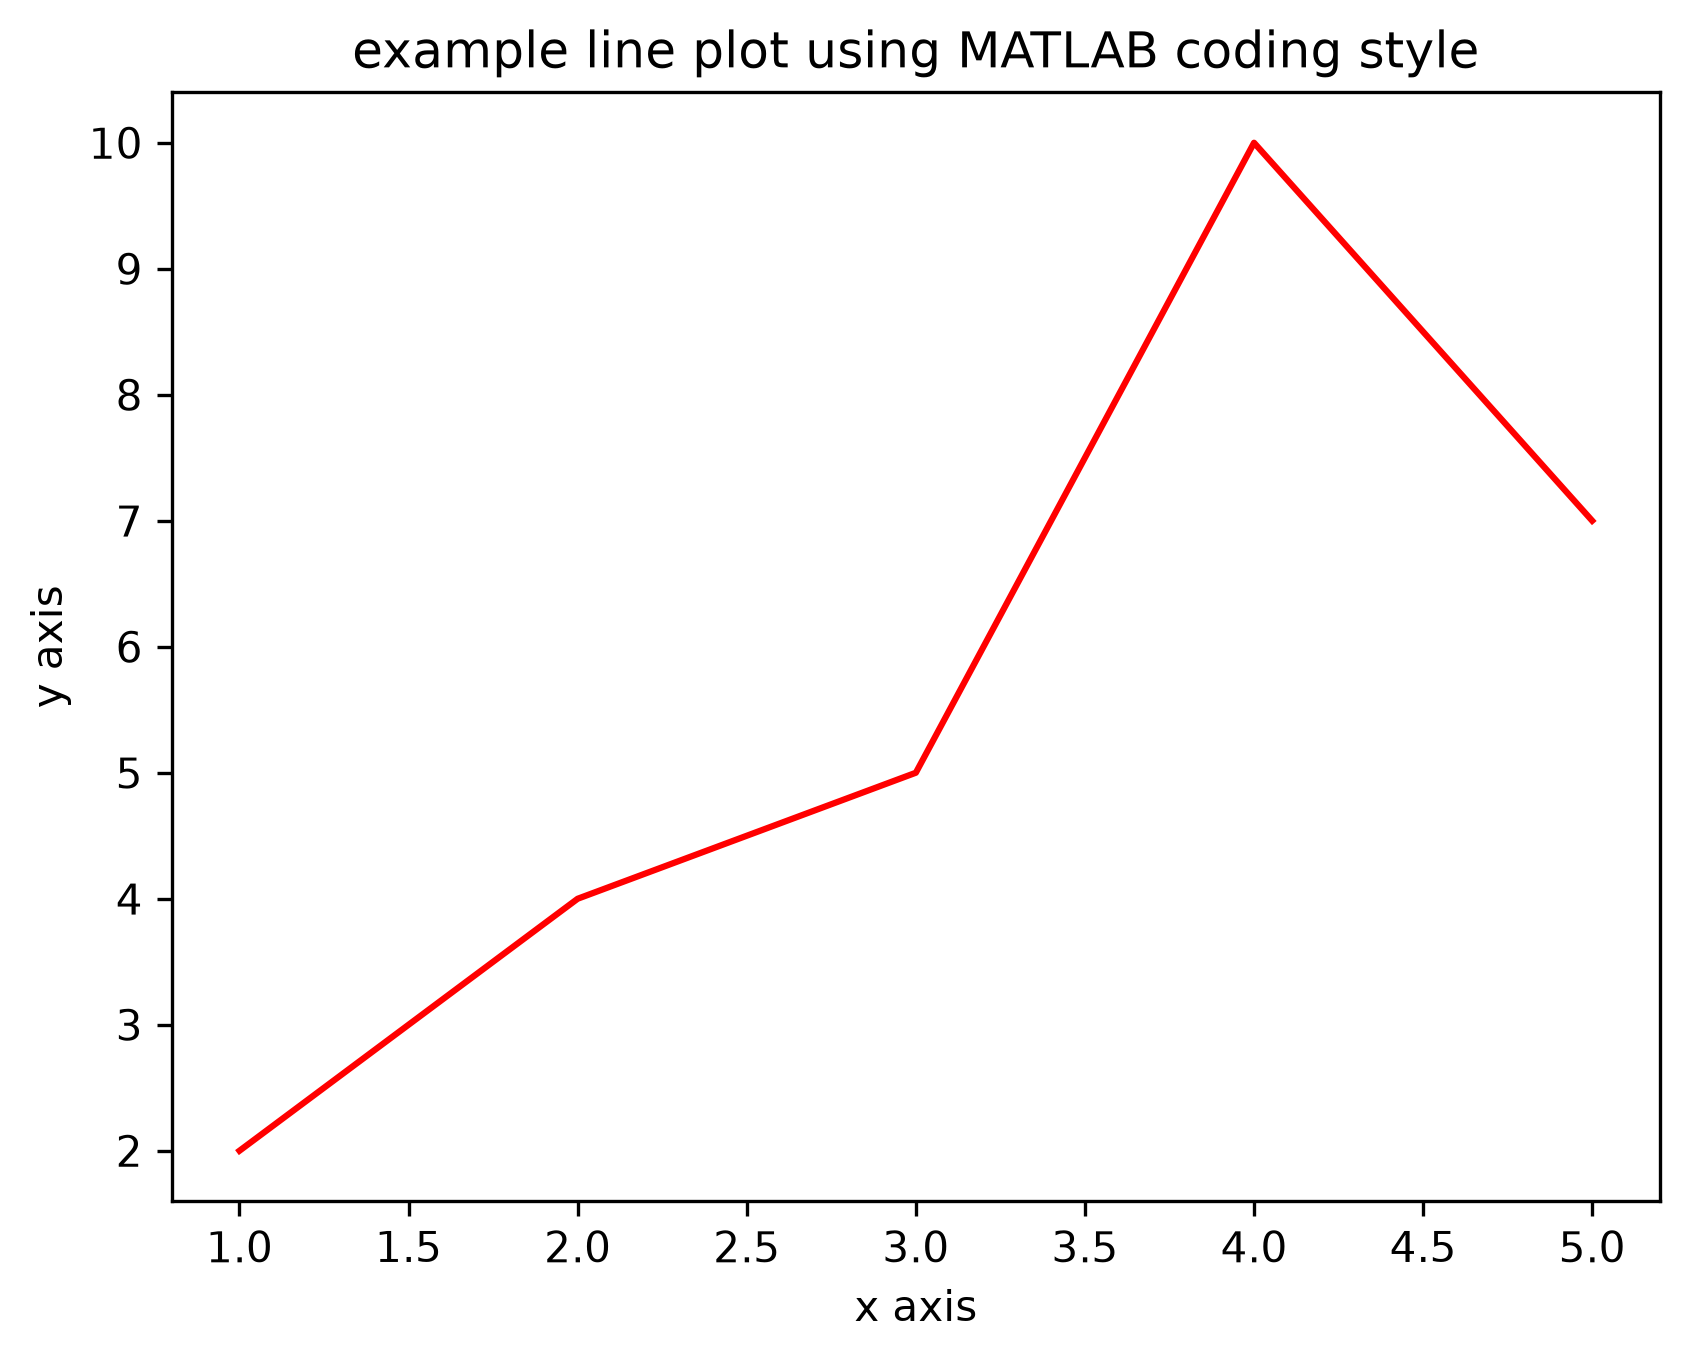

In [111]:
plt.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('example line plot using MATLAB coding style');

Beautiful!

### Basic styling

Before we dive into the myriad plot types that Matplotlib offers, let's first talk about some of the fundamental features they all share: styling and colors. Matplotlib provides a very wide range of styling choices (like line width, line style, and marker style), and an even wider range of colors. 



Let's start with adjusting colors. When you draw multiple lines on a plot, Matplotlib automatically cycles through a preset color "cycler":

(0.9, 5.3)

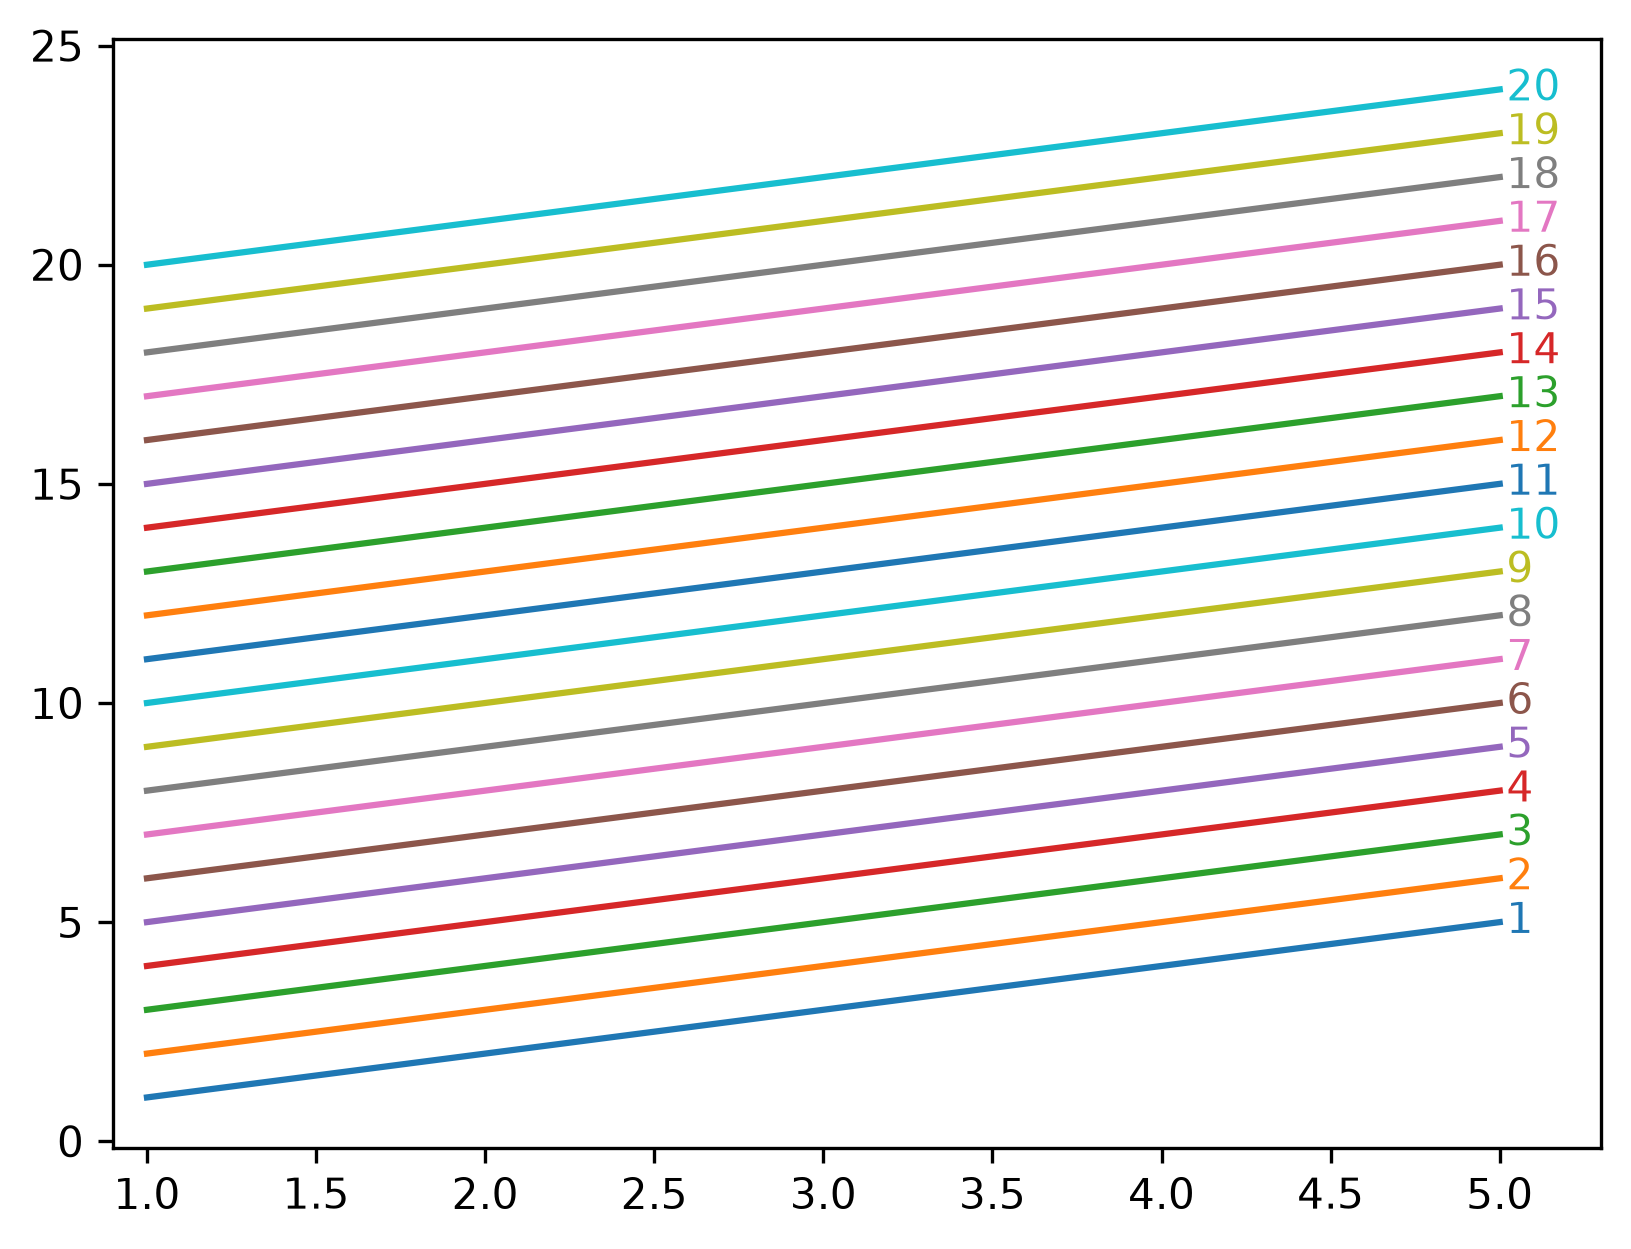

In [173]:
for i in range(20):
    a = plt.plot([1,5], [1+i, 5+i]) # plot the line
    c = a[0].get_color() # retrieve the color
    plt.text(5.02, 5+i, i+1, color=c, va='center') # assign the color to the text
plt.xlim(0.9, 5.3)

This shows us that the preset color cycler contains 10 colors. That's very convenient! So no need to worry about colors when doing some quick plotting — Matplotlib will do that for you.

However, in case you wanted to set up your very own palette, there is almost an infinite number of colors you can choose from, and so many ways to define them! Here are a few:
- Single-character shorthand notation for a few basic colors: `rgbcmykw` for red, green, blue, cyan, magenta, yellow, black, and white.
- Named preset colors from Tableau, CSS4, and XKCD like `'lightcoral'`, `'darkturquoise'`, and `'peachpuff'`. A comprehensive list can found [here](https://matplotlib.org/stable/gallery/color/named_colors.html).
- Tuple of RGB or RGBA code, where A is the alpha, or the transparency (0 for fully transparent to 1 for fully opaque)
- HEX code for RGB or RGBA (i.e. `"#DC143C"` for crimson)
- A string representation of a number between 0 and 1 representing a grayscale (0 is black, 1 is white, everything in between is the proverbial gray area)

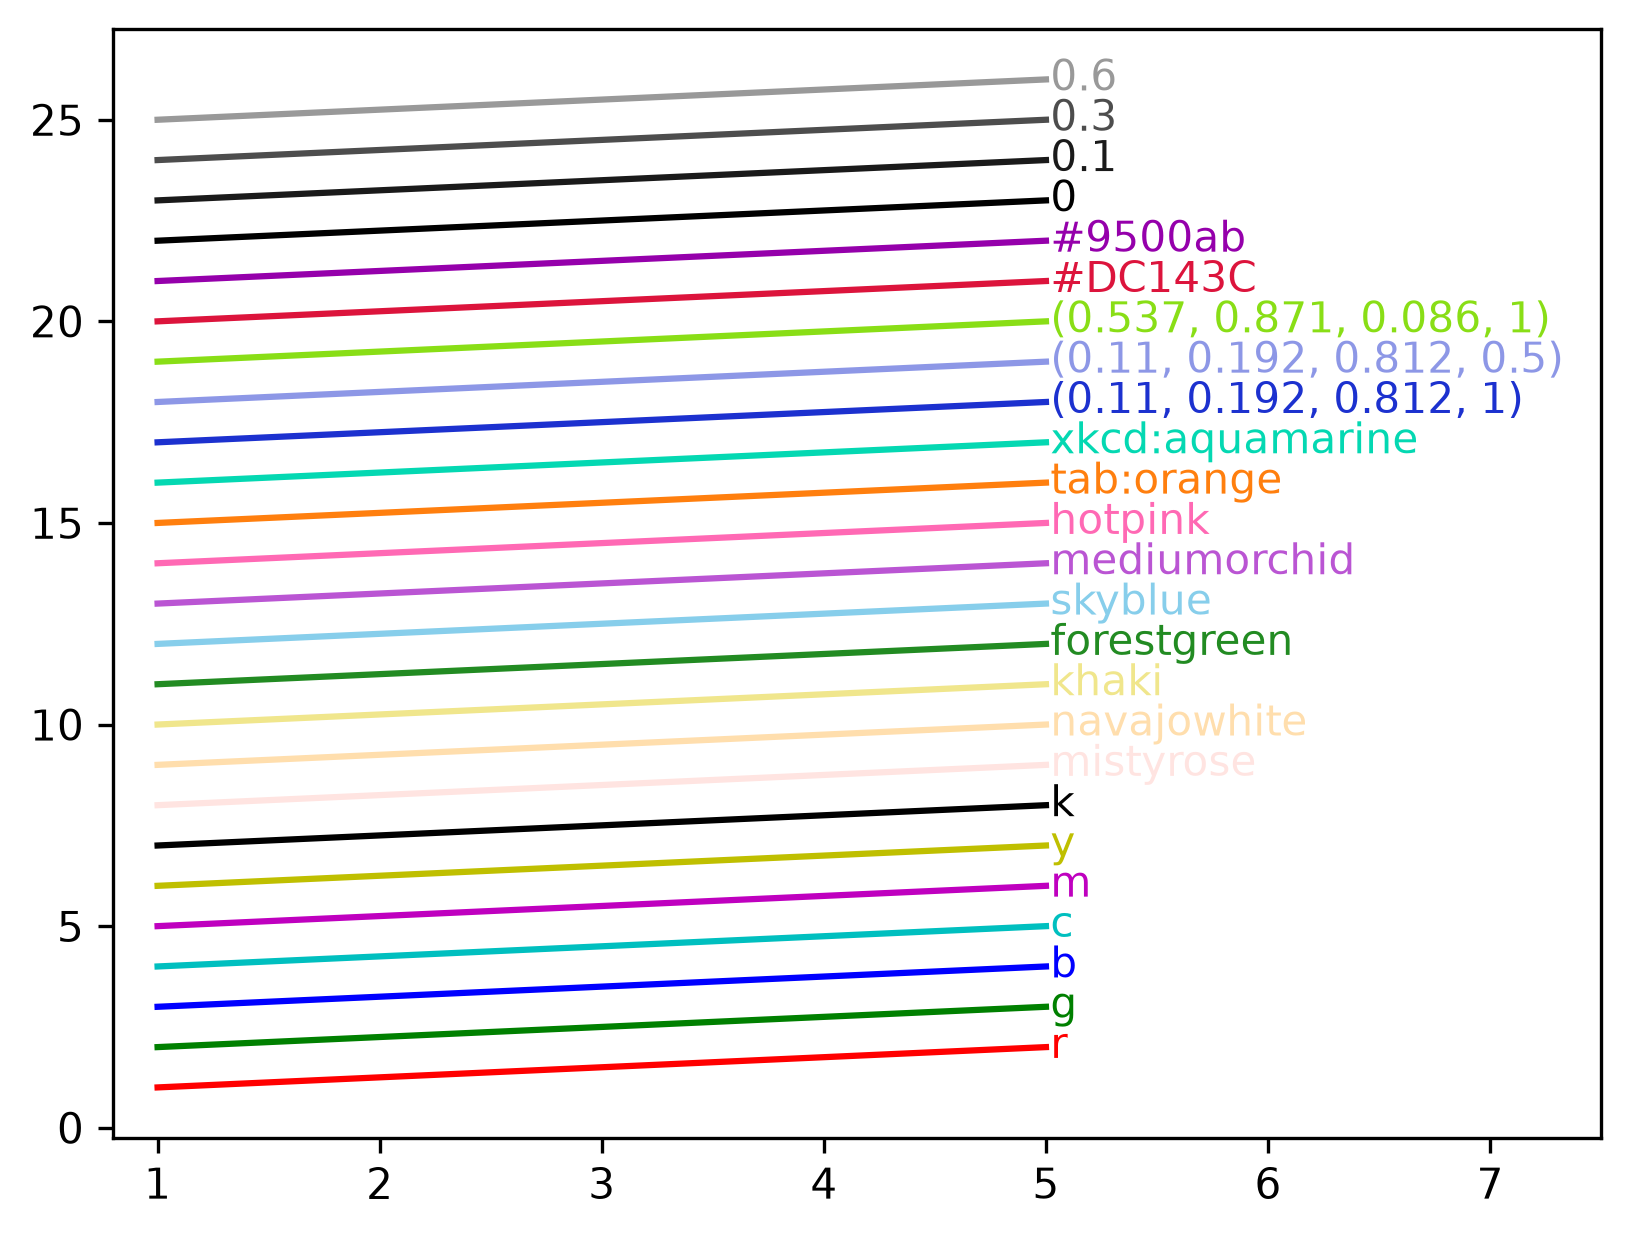

In [178]:
color_list = list('rgbcmyk') + ['mistyrose', 'navajowhite', 'khaki', 'forestgreen', 'skyblue', 'mediumorchid', 'hotpink', 'tab:orange', 'xkcd:aquamarine', (0.11, 0.192, 0.812, 1), (0.11, 0.192, 0.812, 0.5), (0.537, 0.871, 0.086, 1), '#DC143C', '#9500ab', '0', '0.1', '0.3', '0.6']

for i, color in enumerate(color_list):
    plt.plot([1,5], [1+i, 2+i], color=color)
    plt.text(5.02, 2+i, color, color=color, va='center')
plt.xlim(0.8, 7.5);